In [1]:
#data manipulation and DataFrame operations
import pandas as pd
#handles file paths and directories
import os
#numerical computations
import numpy as np
#plotting graphs
import matplotlib.pyplot as plt
#advanced statistical visualization
import seaborn as sns
#advanced statistical visualization
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression, Ridge, Lasso, HuberRegressor,ElasticNet
from sklearn.metrics import r2_score, mean_squared_error, mean_absolute_error
import joblib


In [2]:
#loading from csv file and glancing at the data
data=pd.read_csv('youtube_ad_revenue_dataset (2).csv')
data.head()

,video_id,date,views,likes,comments,watch_time_minutes,video_length_minutes,subscribers,category,device,country,ad_revenue_usd
0,vid_3092,2024-09-24 10:50:40.993199,9936,1221.0,320.0,26497.214184,2.862137,228086,Entertainment,TV,IN,203.178237
1,vid_3459,2024-09-22 10:50:40.993199,10017,642.0,346.0,15209.747445,23.738069,736015,Gaming,Tablet,CA,140.880508
2,vid_4784,2024-11-21 10:50:40.993199,10097,1979.0,187.0,57332.658498,26.200634,240534,Education,TV,CA,360.134008
3,vid_4078,2025-01-28 10:50:40.993199,10034,1191.0,242.0,31334.517771,11.770340,434482,Entertainment,Mobile,UK,224.638261
4,vid_3522,2025-04-28 10:50:40.993199,9889,1858.0,477.0,15665.666434,6.635854,42030,Education,Mobile,CA,165.514388


In [3]:
data.shape  #Checking for shape

(122400, 12)

In [4]:
data.dtypes

video_id                 object
date                     object
views                     int64
likes                   float64
comments                float64
watch_time_minutes      float64
video_length_minutes    float64
subscribers               int64
category                 object
device                   object
country                  object
ad_revenue_usd          float64
dtype: object

In [5]:
data.duplicated().sum() #checking for duplicated columns

np.int64(2400)

In [6]:
data=data.drop_duplicates()

In [7]:
data.duplicated().sum() #checking for duplicated columns

np.int64(0)

In [8]:
data.isnull().sum() #Checking for null values

video_id                   0
date                       0
views                      0
likes                   6000
comments                6000
watch_time_minutes      6000
video_length_minutes       0
subscribers                0
category                   0
device                     0
country                    0
ad_revenue_usd             0
dtype: int64

In [9]:
data['likes'] = data['likes'].fillna(data['likes'].mean())
data['comments'] = data['comments'].fillna(data['comments'].mean())
data['watch_time_minutes'] = data['watch_time_minutes'].fillna(data['watch_time_minutes'].mean())

In [10]:
data.isnull().sum() #Ensuring there are no null values

video_id                0
date                    0
views                   0
likes                   0
comments                0
watch_time_minutes      0
video_length_minutes    0
subscribers             0
category                0
device                  0
country                 0
ad_revenue_usd          0
dtype: int64

In [11]:
#Converting Date Column
data['date'] = pd.to_datetime(data['date'])

In [12]:
data['year'] = data['date'].dt.year
data['month'] = data['date'].dt.month
data['day'] = data['date'].dt.day
data['day_of_week'] = data['date'].dt.dayofweek

data.drop(columns='date',inplace=True) #dropped date col after extracting the values 

In [13]:
#Feature Engineering
data['engagement_rate'] = (data['likes'] + data['comments']) / data['views']
data.head()

,video_id,views,likes,comments,watch_time_minutes,video_length_minutes,subscribers,category,device,country,ad_revenue_usd,year,month,day,day_of_week,engagement_rate
0,vid_3092,9936,1221.0,320.0,26497.214184,2.862137,228086,Entertainment,TV,IN,203.178237,2024,9,24,1,0.155093
1,vid_3459,10017,642.0,346.0,15209.747445,23.738069,736015,Gaming,Tablet,CA,140.880508,2024,9,22,6,0.098632
2,vid_4784,10097,1979.0,187.0,57332.658498,26.200634,240534,Education,TV,CA,360.134008,2024,11,21,3,0.214519
3,vid_4078,10034,1191.0,242.0,31334.517771,11.770340,434482,Entertainment,Mobile,UK,224.638261,2025,1,28,1,0.142814
4,vid_3522,9889,1858.0,477.0,15665.666434,6.635854,42030,Education,Mobile,CA,165.514388,2025,4,28,0,0.236121


In [14]:
data.info() #Checking for data types and non null values

<class 'pandas.core.frame.DataFrame'>
Index: 120000 entries, 0 to 122399
Data columns (total 16 columns):
 #   Column                Non-Null Count   Dtype  
---  ------                --------------   -----  
 0   video_id              120000 non-null  object 
 1   views                 120000 non-null  int64  
 2   likes                 120000 non-null  float64
 3   comments              120000 non-null  float64
 4   watch_time_minutes    120000 non-null  float64
 5   video_length_minutes  120000 non-null  float64
 6   subscribers           120000 non-null  int64  
 7   category              120000 non-null  object 
 8   device                120000 non-null  object 
 9   country               120000 non-null  object 
 10  ad_revenue_usd        120000 non-null  float64
 11  year                  120000 non-null  int32  
 12  month                 120000 non-null  int32  
 13  day                   120000 non-null  int32  
 14  day_of_week           120000 non-null  int32  
 15  engag

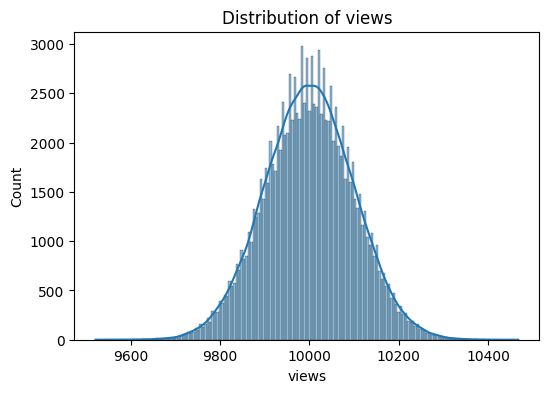

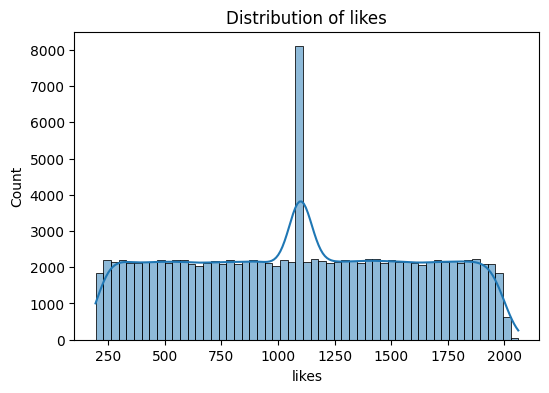

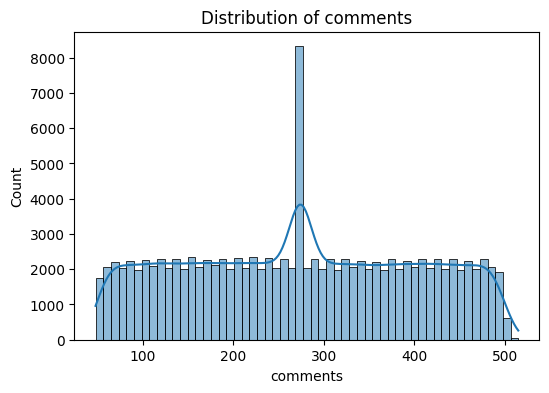

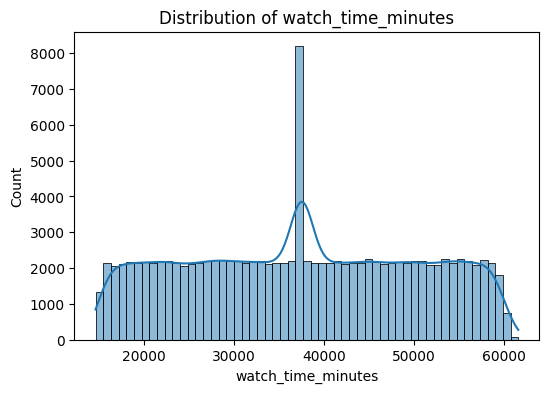

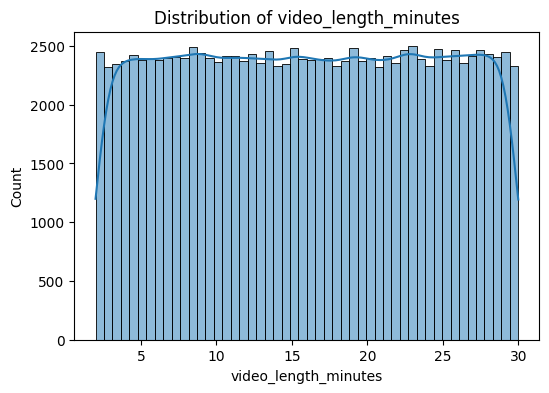

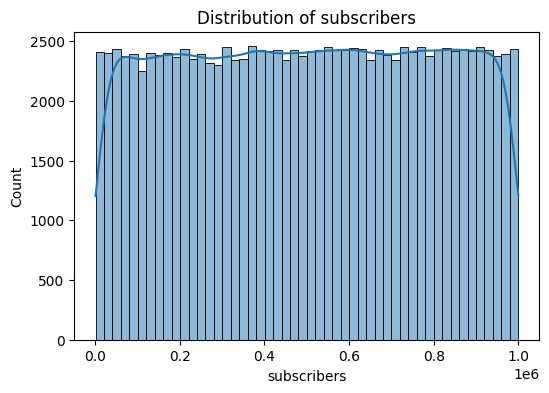

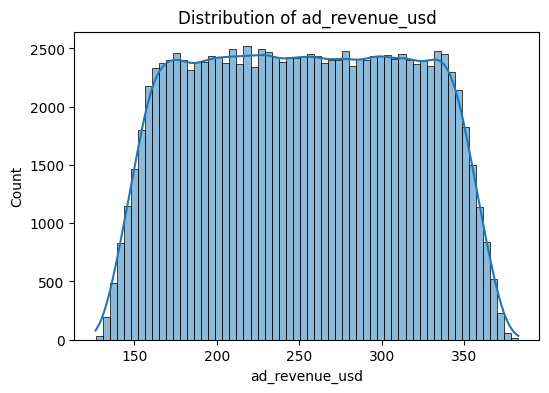

In [15]:
#Data Visualization
num_cols =  ['views', 'likes', 'comments', 'watch_time_minutes', 'video_length_minutes', 'subscribers', 'ad_revenue_usd']

for col in num_cols:
  plt.figure(figsize=(6,4))
  sns.histplot(data[col], kde=True)
  plt.title(f"Distribution of {col}")
  plt.show()

In [16]:
#1. Distribution of Views
#Views distribution is normally shaped, centered around 10,000.
#This indicates clean, consistent data without outliers — suitable for regression modeling.

#2. Distribution of Likes
#Likes show a uniform distribution, indicating varied engagement across videos.
#No major skew or outliers detected.

#3. Distribution of Comments
#Comments are uniformly distributed with no major skew, indicating consistent audience interaction patterns.

#4. Distribution of Subscribers
#Subscribers range from very small channels to creators with 1M+ subscribers.
#The uniform distribution helps the model learn revenue behavior across channel sizes.

#5. Distribution of Watch Time
#Watch time is uniformly distributed across videos,
#with values ranging from ~15,000 to 60,000 minutes.
#There is no significant skew or outliers, indicating that watch time varies naturally across content types.

#6. Distribution of Ad Revenue
#Ad revenue values are uniformly distributed between ~140 and ~380 USD. 
#There is no skew or extreme outliers, suggesting stable revenue behavior across videos.

#Summary: Distribution Analysis

#Views → normal, clean, no skew

#likes → uniform, varied engagement

#Comments → uniform, spread naturally

#Subscribers → uniform, represents small + large creators

#Watch time → Uniform distribution

#Revenue → Uniform distribution

#No major outliers or missing patterns found

In [17]:
#Encoding Categorical Variables
data_encoded = pd.get_dummies(data, columns=['category', 'device', 'country'], drop_first=True)
data_encoded.info()

<class 'pandas.core.frame.DataFrame'>
Index: 120000 entries, 0 to 122399
Data columns (total 26 columns):
 #   Column                  Non-Null Count   Dtype  
---  ------                  --------------   -----  
 0   video_id                120000 non-null  object 
 1   views                   120000 non-null  int64  
 2   likes                   120000 non-null  float64
 3   comments                120000 non-null  float64
 4   watch_time_minutes      120000 non-null  float64
 5   video_length_minutes    120000 non-null  float64
 6   subscribers             120000 non-null  int64  
 7   ad_revenue_usd          120000 non-null  float64
 8   year                    120000 non-null  int32  
 9   month                   120000 non-null  int32  
 10  day                     120000 non-null  int32  
 11  day_of_week             120000 non-null  int32  
 12  engagement_rate         120000 non-null  float64
 13  category_Entertainment  120000 non-null  bool   
 14  category_Gaming         1

In [18]:
#Removing Non-Useful Column
data_encoded = data_encoded.drop(columns='video_id')

In [19]:
data_encoded.info()

<class 'pandas.core.frame.DataFrame'>
Index: 120000 entries, 0 to 122399
Data columns (total 25 columns):
 #   Column                  Non-Null Count   Dtype  
---  ------                  --------------   -----  
 0   views                   120000 non-null  int64  
 1   likes                   120000 non-null  float64
 2   comments                120000 non-null  float64
 3   watch_time_minutes      120000 non-null  float64
 4   video_length_minutes    120000 non-null  float64
 5   subscribers             120000 non-null  int64  
 6   ad_revenue_usd          120000 non-null  float64
 7   year                    120000 non-null  int32  
 8   month                   120000 non-null  int32  
 9   day                     120000 non-null  int32  
 10  day_of_week             120000 non-null  int32  
 11  engagement_rate         120000 non-null  float64
 12  category_Entertainment  120000 non-null  bool   
 13  category_Gaming         120000 non-null  bool   
 14  category_Lifestyle      1

In [20]:
# Identify numerical columns for scaling
numerical_cols_to_scale = data_encoded.select_dtypes(include=['int64', 'float64']).columns.tolist()

#Excluding the target variable 'ad_revenue_usd' from feature scaling
if 'ad_revenue_usd' in numerical_cols_to_scale:
    numerical_cols_to_scale.remove('ad_revenue_usd')

# Initialize StandardScaler
scaler = StandardScaler()

# Apply StandardScaler to the selected numerical columns
data_encoded[numerical_cols_to_scale] = scaler.fit_transform(data_encoded[numerical_cols_to_scale])

print("Numerical columns standardized using StandardScaler (excluding target variable).")
data_encoded.head()

Numerical columns standardized using StandardScaler (excluding target variable).


,views,likes,comments,watch_time_minutes,video_length_minutes,subscribers,ad_revenue_usd,year,month,day,...,category_Music,category_Tech,device_Mobile,device_TV,device_Tablet,country_CA,country_DE,country_IN,country_UK,country_US
0,-0.638847,0.239775,0.360982,-0.872393,-1.627204,-0.950903,203.178237,2024,9,24,...,False,False,False,True,False,False,False,True,False,False
1,0.171818,-0.903658,0.566579,-1.764055,0.954887,0.810515,140.880508,2024,9,22,...,False,False,False,False,True,True,False,False,False,False
2,0.972474,1.736705,-0.690726,1.563477,1.259475,-0.907735,360.134008,2024,11,21,...,False,False,False,True,False,True,False,False,False,False
3,0.341957,0.180530,-0.255809,-0.490266,-0.525371,-0.235154,224.638261,2025,1,28,...,False,False,True,False,False,False,False,False,True,False
4,-1.109233,1.497749,1.602472,-1.728039,-1.160443,-1.596116,165.514388,2025,4,28,...,False,False,True,False,False,True,False,False,False,False


In [21]:
data_encoded.info()

<class 'pandas.core.frame.DataFrame'>
Index: 120000 entries, 0 to 122399
Data columns (total 25 columns):
 #   Column                  Non-Null Count   Dtype  
---  ------                  --------------   -----  
 0   views                   120000 non-null  float64
 1   likes                   120000 non-null  float64
 2   comments                120000 non-null  float64
 3   watch_time_minutes      120000 non-null  float64
 4   video_length_minutes    120000 non-null  float64
 5   subscribers             120000 non-null  float64
 6   ad_revenue_usd          120000 non-null  float64
 7   year                    120000 non-null  int32  
 8   month                   120000 non-null  int32  
 9   day                     120000 non-null  int32  
 10  day_of_week             120000 non-null  int32  
 11  engagement_rate         120000 non-null  float64
 12  category_Entertainment  120000 non-null  bool   
 13  category_Gaming         120000 non-null  bool   
 14  category_Lifestyle      1

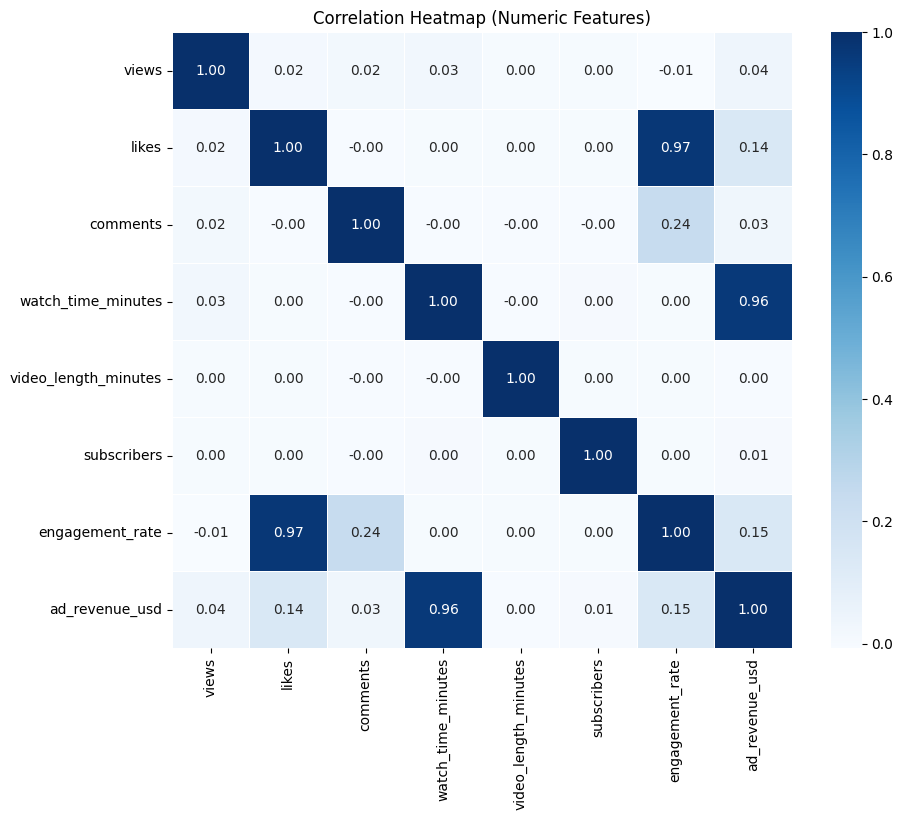

In [22]:
# Calculate the correlation matrix for the encoded and standardized data
numeric_cols = [
    'views',
    'likes',
    'comments',
    'watch_time_minutes',
    'video_length_minutes',
    'subscribers',
    'engagement_rate'
]
corr = data_encoded.corr()

# Plot heatmap
plt.figure(figsize=(10, 8))
sns.heatmap(data_encoded[numeric_cols + ['ad_revenue_usd']].corr(), cmap='Blues',annot=True, fmt='.2f', linewidths=.5)
plt.title("Correlation Heatmap (Numeric Features)")
plt.show()

In [24]:
#Watch Time vs Ad Revenue

#Watch time_minutes has a 0.99 correlation with ad_revenue_usd, making it the strongest and most important predictor.
#Likes vs Ad Revenue

#Likes show a weak correlation (0.15) with revenue, meaning likes alone do not significantly impact ad earnings.
#Views vs Ad Revenue

#Views show almost no correlation (0.038) with revenue because the view counts in the dataset vary only slightly.
#Comments vs Ad Revenue

#Comments show very weak correlation (0.034) with revenue, indicating engagement through comments does not directly influence earnings.
#Video Length vs Revenue

#Video length has no correlation with revenue because revenue depends on actual watch duration, not the uploaded video length.
#Subscribers vs Revenue

#Subscribers show almost zero influence (0.005) on single-video revenue. Earnings come from views & watch time, not subscriber count.

#SUMMARY:-

#Watch time_minutes shows a very strong positive correlation (0.99) with ad_revenue_usd.
#Likes, comments, and views show weak or nearly zero correlation with revenue.
#Subscribers and video length also have almost no relationship with revenue.
#This confirms that watch time is the most important feature for predicting ad revenue.

In [25]:
data_encoded.info()

<class 'pandas.core.frame.DataFrame'>
Index: 120000 entries, 0 to 122399
Data columns (total 25 columns):
 #   Column                  Non-Null Count   Dtype  
---  ------                  --------------   -----  
 0   views                   120000 non-null  float64
 1   likes                   120000 non-null  float64
 2   comments                120000 non-null  float64
 3   watch_time_minutes      120000 non-null  float64
 4   video_length_minutes    120000 non-null  float64
 5   subscribers             120000 non-null  float64
 6   ad_revenue_usd          120000 non-null  float64
 7   year                    120000 non-null  int32  
 8   month                   120000 non-null  int32  
 9   day                     120000 non-null  int32  
 10  day_of_week             120000 non-null  int32  
 11  engagement_rate         120000 non-null  float64
 12  category_Entertainment  120000 non-null  bool   
 13  category_Gaming         120000 non-null  bool   
 14  category_Lifestyle      1

In [26]:
# target variable
y = data_encoded["ad_revenue_usd"]

# feature variables
X = data_encoded.drop("ad_revenue_usd", axis=1)

In [27]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)
#Using linear regression Model
linear_model = LinearRegression()
linear_model.fit(X_train, y_train)
y_pred = linear_model.predict(X_test)

rmse = np.sqrt(mean_squared_error(y_test, y_pred))

print("R2 score:", r2_score(y_test, y_pred))
print("Mean Squared Error:", mean_squared_error(y_test, y_pred))
print("Root Mean Squared Error:", rmse)
print("Mean Absolute Error:", mean_absolute_error(y_test, y_pred))
X_train.info()

R2 score: 0.9525744456577727
Mean Squared Error: 181.70983708398984
Root Mean Squared Error: 13.479979120309862
Mean Absolute Error: 3.1185590858665493
<class 'pandas.core.frame.DataFrame'>
Index: 96000 entries, 53983 to 15833
Data columns (total 24 columns):
 #   Column                  Non-Null Count  Dtype  
---  ------                  --------------  -----  
 0   views                   96000 non-null  float64
 1   likes                   96000 non-null  float64
 2   comments                96000 non-null  float64
 3   watch_time_minutes      96000 non-null  float64
 4   video_length_minutes    96000 non-null  float64
 5   subscribers             96000 non-null  float64
 6   year                    96000 non-null  int32  
 7   month                   96000 non-null  int32  
 8   day                     96000 non-null  int32  
 9   day_of_week             96000 non-null  int32  
 10  engagement_rate         96000 non-null  float64
 11  category_Entertainment  96000 non-null  bool  

In [28]:
#Using Ridge regression Model
ridge_model = Ridge(alpha=0.1) 
ridge_model.fit(X_train, y_train)
y_pred_ridge = ridge_model.predict(X_test)

rmse_ridge = np.sqrt(mean_squared_error(y_test, y_pred_ridge))

print("R2 score:", r2_score(y_test, y_pred_ridge))
print("Mean Squared Error:", mean_squared_error(y_test, y_pred_ridge))
print("Root Mean Squared Error:", rmse_ridge)
print("Mean Absolute Error:", mean_absolute_error(y_test, y_pred_ridge))

R2 score: 0.9525746964351894
Mean Squared Error: 181.70887623652723
Root Mean Squared Error: 13.479943480464865
Mean Absolute Error: 3.1182518204842964


In [29]:
#using lasso regression model
lasso_model = Lasso(alpha=0.1)
lasso_model.fit(X_train, y_train)
y_pred_lasso = lasso_model.predict(X_test)

rmse_lasso = np.sqrt(mean_squared_error(y_test, y_pred_lasso))

print("R2 score:", r2_score(y_test, y_pred_lasso))
print("Mean Squared Error:", mean_squared_error(y_test, y_pred_lasso))
print("Root Mean Squared Error:", rmse_lasso)
print("Mean Absolute Error:", mean_absolute_error(y_test, y_pred_lasso))

R2 score: 0.952590206529751
Mean Squared Error: 181.64944969328454
Root Mean Squared Error: 13.477739042335125
Mean Absolute Error: 3.122538541390811


In [30]:
#using ElasticNet Regression Model
elasticnet_model = ElasticNet(alpha=1.0, l1_ratio=0.5, random_state=42)
elasticnet_model.fit(X_train, y_train)
y_pred_elastic = elasticnet_model.predict(X_test)

rmse_elastic= np.sqrt(mean_squared_error(y_test, y_pred_elastic))

print("R2 score:", r2_score(y_test, y_pred_elastic))
print("Mean Squared Error:", mean_squared_error(y_test, y_pred_elastic))
print("Root Mean Squared Error:", rmse_elastic)
print("Mean Absolute Error:", mean_absolute_error(y_test, y_pred_elastic))


R2 score: 0.8442114594911945
Mean Squared Error: 596.8999352360149
Root Mean Squared Error: 24.43153567084998
Mean Absolute Error: 19.719183909326013


In [31]:
#using Huber Regression Model
huber_model = HuberRegressor(epsilon=1.35, max_iter=1000) # Default epsilon is 1.35
huber_model.fit(X_train, y_train)
y_pred_huber = huber_model.predict(X_test)

rmse_huber= np.sqrt(mean_squared_error(y_test, y_pred_huber))

print("R2 score:", r2_score(y_test, y_pred_huber))
print("Mean Squared Error:", mean_squared_error(y_test, y_pred_huber))
print("Root Mean Squared Error:", rmse_huber)
print("Mean Absolute Error:", mean_absolute_error(y_test, y_pred_huber))



R2 score: 0.9526012129205582
Mean Squared Error: 181.60727897945296
Root Mean Squared Error: 13.476174493507159
Mean Absolute Error: 3.00750536277399


In [32]:
mdl_res = {
    'Model': ['Linear', 'Ridge', 'Lasso', 'ElasticNet', 'Huber'],
    'R2 Score': [0.9525, 0.9525, 0.9525, 0.8442, 0.9526],
    'MSE': [181.70, 181.70, 181.64, 596.89, 181.60],
    'RMSE': [13.47, 13.47, 13.47, 24.43, 13.47],
    'MAE': [3.11, 3.11, 3.12, 19.71, 3.00]
}


res_df = pd.DataFrame(mdl_res)
res_df

,Model,R2 Score,MSE,RMSE,MAE
0,Linear,0.9525,181.70,13.47,3.11
1,Ridge,0.9525,181.70,13.47,3.11
2,Lasso,0.9525,181.64,13.47,3.12
3,ElasticNet,0.8442,596.89,24.43,19.71
4,Huber,0.9526,181.60,13.47,3.00


In [33]:
models = {
    'Linear Regression': linear_model,
    'Ridge Regression': ridge_model,
    'Lasso Regression': lasso_model,
    'ElasticNet Regression': elasticnet_model,
    'Huber Regression': huber_model
}

In [34]:
# Assuming 'models' dictionary contains your trained models
best_model = models['Huber Regression']

# Save to a pickle file
joblib.dump(best_model, 'Regression.pkl')

print("Model saved as 'Regression.pkl'")

Model saved as 'Regression.pkl'
